In [3]:
import os
from os.path import expanduser
home = expanduser("~/")

import sys
sys.path.insert(0, home+'/gigalens'+'/src')
sys.path.insert(0, home+'/GIGALens-Code')
print('MASTER BRANCH GIGALENS')

srcdir = os.path.join(home, "gigalens/src/")

MASTER BRANCH GIGALENS


In [4]:
from gigalens.jax.inference import HarryModellingSequence
from gigalens.jax.model import ForwardProbModel, BackwardProbModel
from gigalens.model import PhysicalModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles.light import sersic
from gigalens.jax.profiles.mass import epl, shear

import tensorflow_probability.substrates.jax as tfp
import jax
from jax import random
import numpy as np
import optax
from jax import numpy as jnp
from matplotlib import pyplot as plt
import optax
from helpers import *
tfd = tfp.distributions



/global/homes/l/linusu/.conda/envs/jax-gigalens-multinode/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/global/homes/l/linusu//gigalens/src/gigalens/jax/inference.py:28: UserWarning: jax.distributed.initialize() was not called. For multinode, please call it before running any JAX functions.
  warnings.warn('jax.distributed.initialize() was not called. For multinode, please call it before running any JAX functions.')


ImportError: cannot import name 'HarryModellingSequence' from 'gigalens.jax.inference' (/global/homes/l/linusu//gigalens/src/gigalens/jax/inference.py)

In [5]:
import json
from myfunctions import readJson

prior, phys_model_back, phys_model_for, singlesources = readJson("prior_shapelets.json")

In [6]:
prior

<tfp.distributions.JointDistributionSequential 'JointDistributionSequential' batch_shape=[[{center_x: [], center_y: [], e1: [], e2: [], gamma: [], theta_E: []}, {gamma1: [], gamma2: []}], [{R_sersic: [], center_x: [], center_y: [], e1: [], e2: [], n_sersic: []}, {R_sersic: [], center_x: [], center_y: [], e1: [], e2: [], n_sersic: []}, {R_sersic: [], center_x: [], center_y: [], e1: [], e2: [], n_sersic: []}], [{beta: [], center_x: [], center_y: []}]] event_shape=[[{center_x: [], center_y: [], e1: [], e2: [], gamma: [], theta_E: []}, {gamma1: [], gamma2: []}], [{R_sersic: [], center_x: [], center_y: [], e1: [], e2: [], n_sersic: []}, {R_sersic: [], center_x: [], center_y: [], e1: [], e2: [], n_sersic: []}, {R_sersic: [], center_x: [], center_y: [], e1: [], e2: [], n_sersic: []}], [{beta: [], center_x: [], center_y: []}]] dtype=[[{center_x: float32, center_y: float32, e1: float32, e2: float32, gamma: float32, theta_E: float32}, {gamma1: float32, gamma2: float32}], [{R_sersic: float32, cen

In [4]:
from astropy.io import fits

f=fits.open('psf238.fits') 
psf=jnp.array(f[0].data).astype(jnp.float32)

observed_img = np.load("cutout238b.npy").astype(np.float32)

f=fits.open('final_94_drz.fits')
background_rms=0.00766512
exp_time=f[0].header["EXPTIME"]
deltaPix = f[0].header["D002SCAL"]
numPix = np.shape(observed_img)[0]
print(f"Numpix:",numPix, "DeltaPix:",deltaPix)

Numpix: 120 DeltaPix: 0.065


In [ ]:
kernel = psf #np.load(os.path.join(srcdir, 'gigalens/assets/psf.npy')).astype(np.float32)
# observed_img = np.load(os.path.join(srcdir, 'gigalens/assets/demo.npy')).astype(np.float32)
sim_config = SimulatorConfig(delta_pix=deltaPix, num_pix=numPix, supersample=2, kernel=kernel)
phys_model = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(use_lstsq=True)], [sersic.SersicEllipse(use_lstsq=True)])
lens_sim = LensSimulator(phys_model_back, sim_config, bs=1)

# systems_dir = os.path.join(home, "GIGALens-Code/SystemSaves")
# f = np.load(os.path.join(systems_dir, "100SystemsStandard80px.npz"))
# observed_imgs = jnp.array([f[key] for key in f.files])

# observed_img = observed_imgs[4]

prob_model = BackwardProbModel(prior, observed_img, background_rms=background_rms, exp_time=exp_time)
model_seq = HarryModellingSequence(phys_model_back, prob_model, sim_config)

In [6]:
map_optimizer = optax.adabelief(1e-2, b1=0.95, b2=0.99) #nesterov=True may not be implemented in current optax
map_estimate, map_loss_hist = model_seq.MAP(map_optimizer, seed=0, n_samples=100, num_steps=350)

2025-09-19 10:05:48.230246: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng28{k2=3,k3=0} for conv %cudnn-conv.2 = (f32[100,18,240,240]{3,2,1,0}, u8[0]{0}) custom-call(%bitcast.673, %constant.802), window={size=53x53 pad=26_26x26_26}, dim_labels=bf01_oi01->bf01, feature_group_count=18, custom_call_target="__cudnn$convForward", metadata={op_name="jit(run_map)/jit(main)/jit(shmap_body)/while/body/jit(loss)/vmap(jvp(jit(log_prob)))/jit(lstsq_simulate)/conv_general_dilated" source_file="/global/homes/l/linusu//gigalens/src/gigalens/jax/simulator.py" source_line=118}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-09-19 10:05:51.941206: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 4.711047188s
Trying algorithm eng2

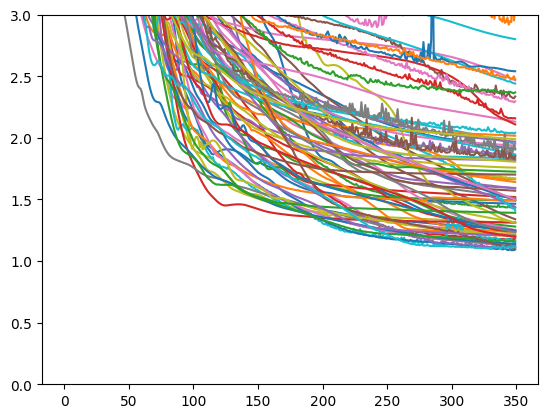

In [7]:
plt.plot(map_loss_hist)
plt.ylim(bottom=0, top=3)
plt.show()

In [8]:
# lps = prob_model.log_prob(LensSimulator(phys_model, sim_config, bs=500), map_estimate)[0]
# best = map_estimate[jnp.nanargmax(lps)][jnp.newaxis,:]
map_loss_history = jnp.min(map_loss_hist, axis=1)
best_step_idx = jnp.argmin(map_loss_history)
best_sample_idx = jnp.argmin(map_loss_hist[best_step_idx])

best = map_estimate[best_step_idx][best_sample_idx][jnp.newaxis, :].reshape((-1, map_estimate.shape[-1]))
best_x = prob_model.bij.forward(list(best.T))

In [9]:
svi_optimizer = optax.adabelief(1e-4, b1=0.95, b2=0.99)
qz, loss_hist = model_seq.SVI(best, svi_optimizer, n_vi=100, num_steps=500)

2025-09-19 10:10:09.789888: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


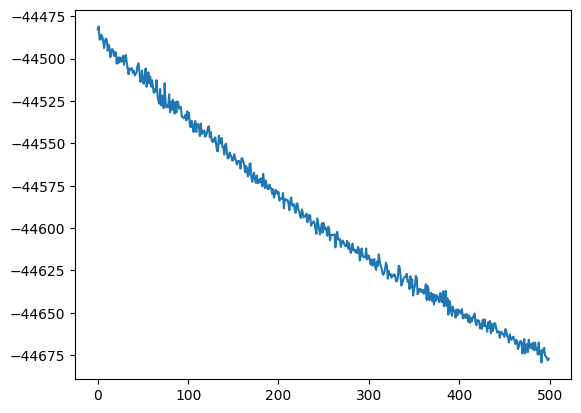

In [10]:
plt.plot(loss_hist)

In [11]:
samples = model_seq.HMC(qz, num_burnin_steps=250, num_results=750)

2025-09-19 10:15:02.941075: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng28{k2=3,k3=0} for conv %cudnn-conv.4 = (f32[50,18,240,240]{3,2,1,0}, u8[0]{0}) custom-call(%select.4842, %constant.9384), window={size=53x53 pad=26_26x26_26}, dim_labels=bf01_oi01->bf01, feature_group_count=18, custom_call_target="__cudnn$convForward", metadata={op_name="pmap(run_chain)/jit(main)/mcmc_sample_chain/dual_averaging_step_size_adaptation___init___bootstrap_results/gradient_based_trajectory_length_adaptation___init_____init___bootstrap_results/mh_bootstrap_results/phmc_kernel_bootstrap_results/phmc_kernel_bootstrap_results/maybe_call_fn_and_grads/value_and_gradients/jvp(jit(log_prob))/jit(log_prob)/jit(lstsq_simulate)/conv_general_dilated" source_file="/global/homes/l/linusu//gigalens/src/gigalens/jax/simulator.py" source_line=118}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kN

In [13]:
smp = jnp.transpose(samples, (1, 2, 0, 3)).reshape((-1, samples.shape[-1]))
hmc_median = jnp.median(smp, axis=0)[jnp.newaxis,:]

In [14]:
rhat= tfp.mcmc.potential_scale_reduction(jnp.transpose(samples, (1,2,0,3)), independent_chain_ndims=2)

In [ ]:
rhat

Array([0.98000664, 0.98001474, 0.9800061 , 0.9800137 , 0.9800106 ,
       0.98001   , 0.98000205, 0.980003  , 0.98000234, 0.9800062 ,
       0.98000395, 0.98000413, 0.9800056 , 0.980004  , 0.9800057 ,
       0.9800023 , 0.980001  , 0.98000175, 0.98000985, 0.9800053 ,
       0.98000675, 0.9800033 , 0.9800037 , 0.98000145, 0.9800025 ,
       0.9800057 , 0.98000735, 0.98000294, 0.98000586], dtype=float32)

: 